## Volume modulation with a low frequency oscillator

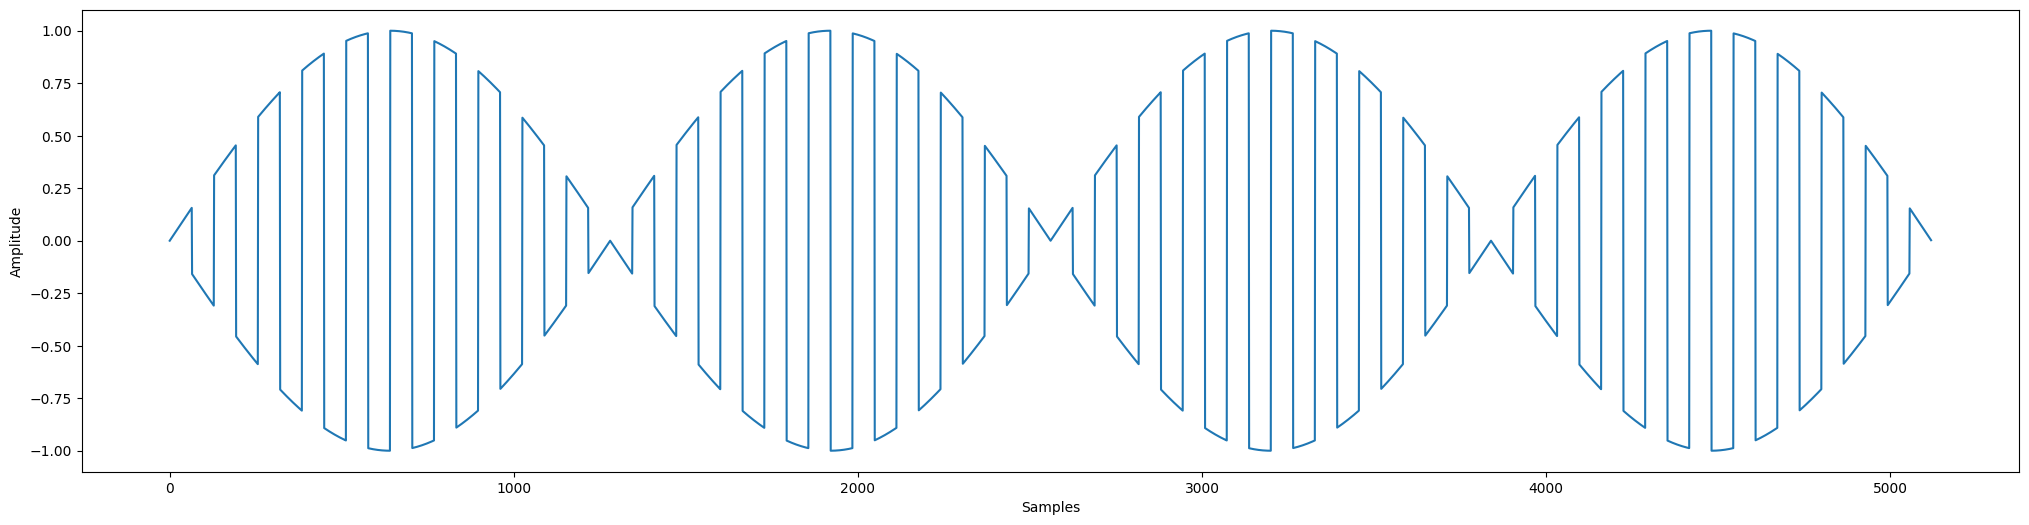

In [1]:
import matplotlib.pyplot as plt

from constants import DEFAULT_SAMPLE_RATE
from engine import Chain, ModulatedVolume, SineOscillator, SquareOscillator

osc1 = SquareOscillator(freq=4, amp=1, phase=0, sample_rate=512)

# Create a low frequency oscillator (LFO) for volume modulation
lfo = SineOscillator(freq=0.2, amp=1, phase=0, sample_rate=512)
vol = ModulatedVolume(lfo)

chain = Chain(osc1, vol)
samples = chain.get_samples(n=512 * 10)

fig, ax = plt.subplots(1, 1, figsize=(25, 6))
plt.ylabel("Amplitude")
plt.xlabel("Samples")
plt.plot(samples)
plt.show()

## Frequency modulation with a low frequency oscillator

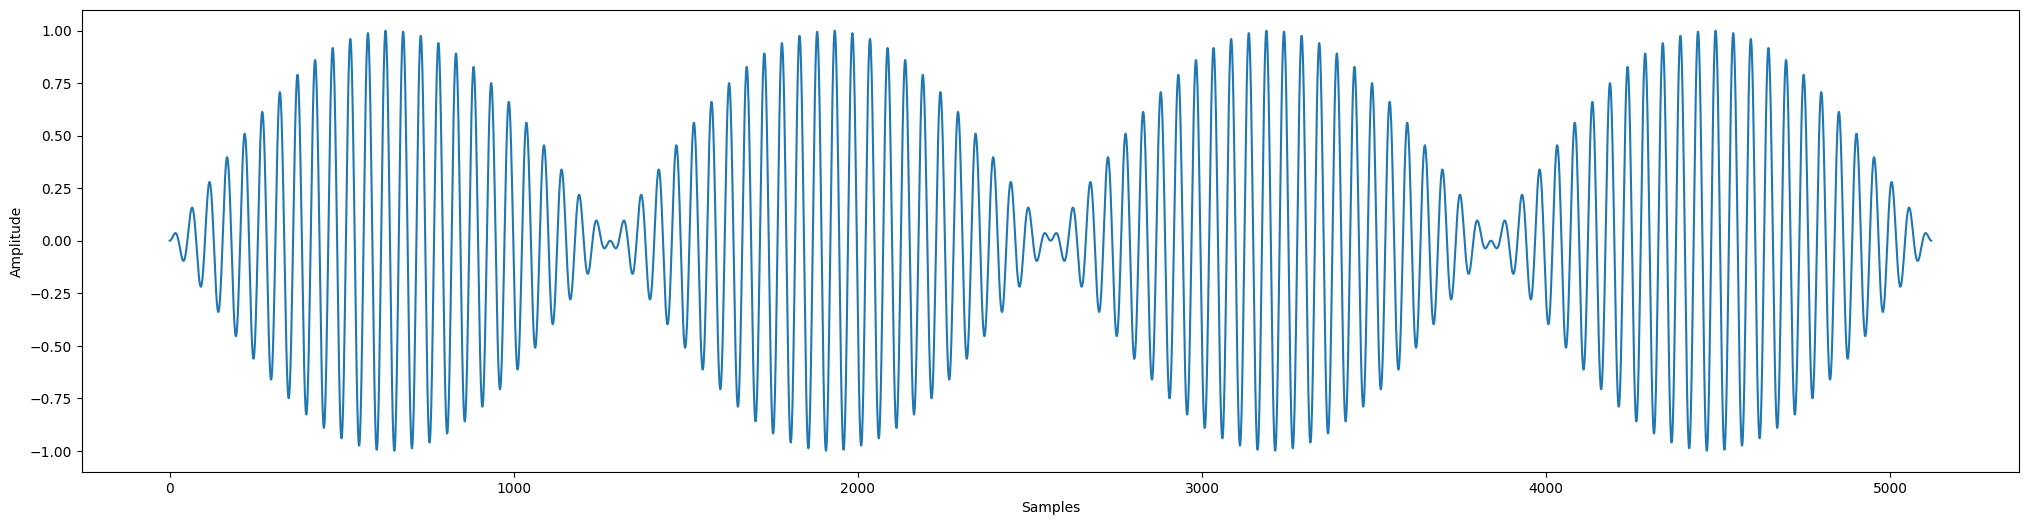

In [2]:
# Todo: fix frequency modulation via ModulatedFrequency class. Not yet working properly

from engine import ModulatedFrequency

osc1 = SineOscillator(freq=10, amp=1, phase=0, sample_rate=512)

# Create a low frequency oscillator (LFO) for volume modulation
lfo = SineOscillator(freq=0.2, amp=1, phase=0, sample_rate=512)
freq_mod = ModulatedFrequency(lfo)

fig, ax = plt.subplots(1, 1, figsize=(25, 6))
chain = Chain(osc1, freq_mod)
samples = chain.get_samples(n=512 * 10)
plt.ylabel("Amplitude")
plt.xlabel("Samples")
plt.plot(samples)
plt.show()

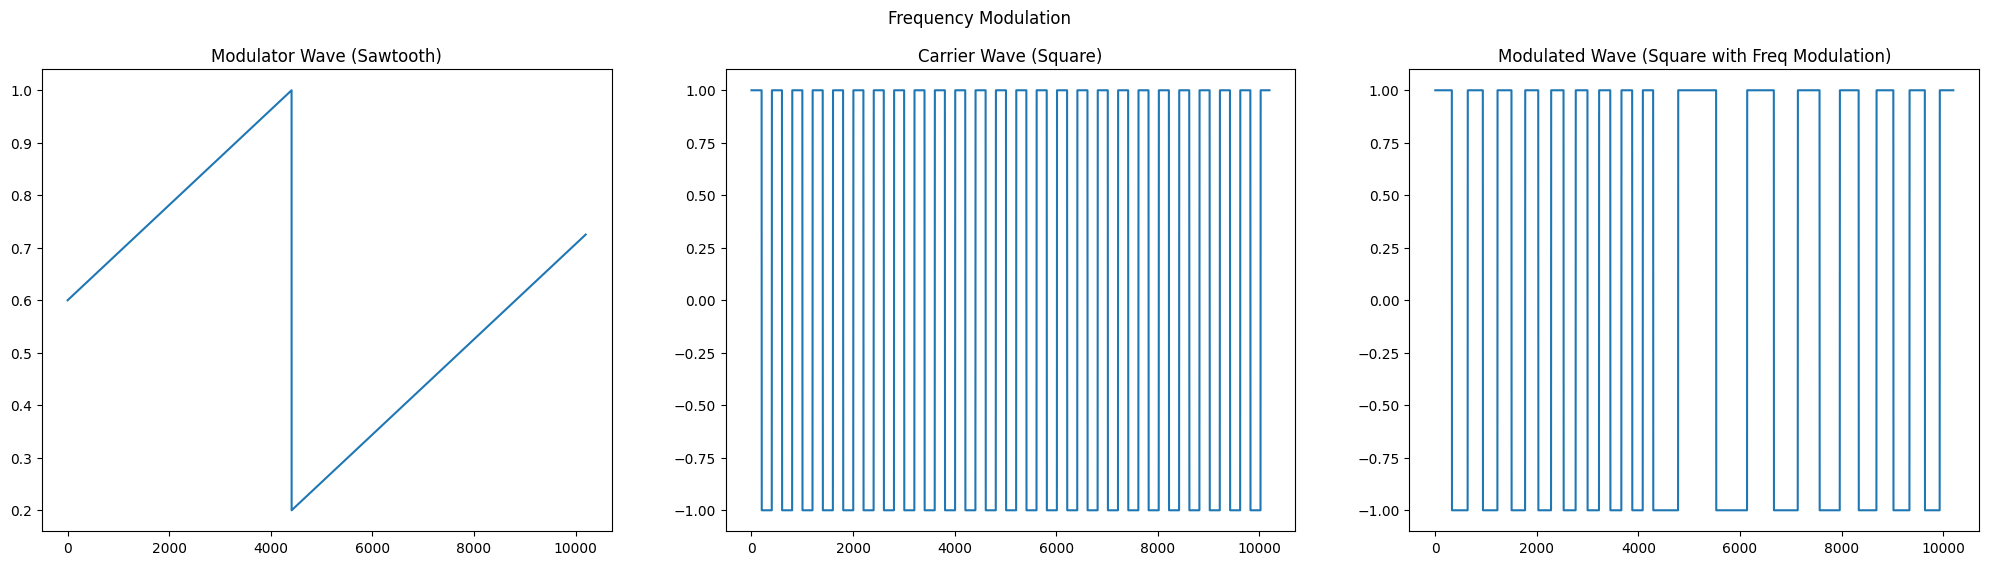

In [3]:
from engine import SawtoothOscillator, ModulatedOscillator


def freq_mod(init_freq, val):
    return init_freq * val


gen = ModulatedOscillator(
    SquareOscillator(freq=110),
    SawtoothOscillator(freq=5, wave_range=(0.2, 1)),
    freq_mod=freq_mod,
)

i = int(512 / 5) * 100
s = gen.oscillator.get_samples()[:i]
q = gen.modulators[0].get_samples()[:i]
g = gen.get_samples()[:i]

fig, ax = plt.subplots(1, 3, figsize=(25, 6))
plt.suptitle("Frequency Modulation")
ax[0].plot(q)
ax[0].set_title("Modulator Wave (Sawtooth)")

ax[1].plot(s)
ax[1].set_title("Carrier Wave (Square)")

ax[2].plot(g)
ax[2].set_title("Modulated Wave (Square with Freq Modulation)")
plt.show()

## Modulation example

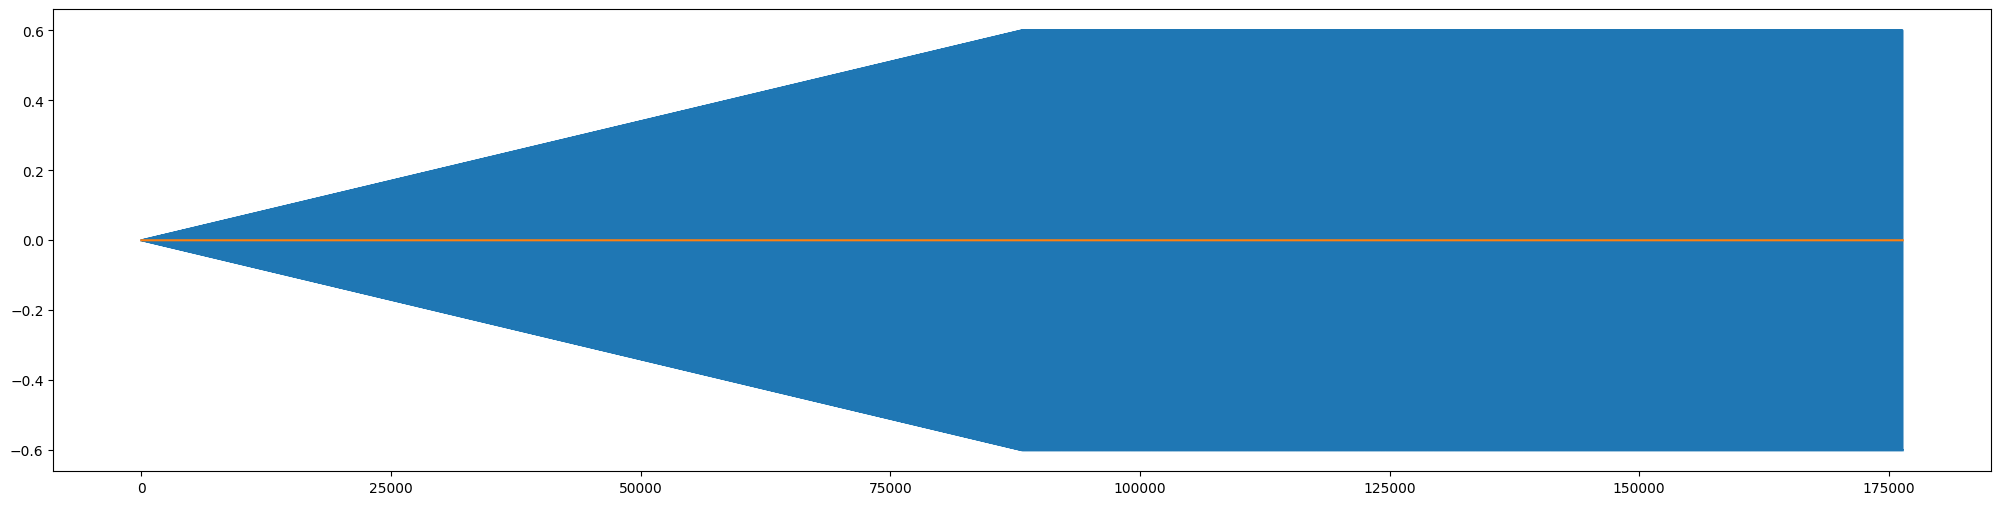

In [4]:
import IPython.display as ipd
from utils import wave_to_file, hz
from engine import TriangleOscillator, ModulatedPanner, Panner, ADSREnvelope, WaveAdder


def amp_mod(init_amp, env):
    return env * init_amp


gen_simple = Chain(
    SquareOscillator(hz("C5"), amp=0.3),
    ModulatedVolume(
        ADSREnvelope(attack_duration=2, decay_duration=0.001, sustain_level=1)
    ),
    ModulatedPanner(TriangleOscillator(1, phase=180, wave_range=(-1, 1))),
)

gen = WaveAdder(
    Chain(
        SquareOscillator(hz("C5"), amp=0.3),
        ModulatedVolume(
            ADSREnvelope(attack_duration=2, decay_duration=0.001, sustain_level=1)
        ),
        ModulatedPanner(TriangleOscillator(1, phase=180, wave_range=(-1, 1))),
    ),
    Chain(
        SquareOscillator(hz("A5"), amp=0.3),
        ModulatedVolume(
            ADSREnvelope(attack_duration=2, decay_duration=0.001, sustain_level=1)
        ),
        ModulatedPanner(TriangleOscillator(1, wave_range=(-1, 1))),
    ),
    Chain(
        ModulatedOscillator(
            SawtoothOscillator(hz("A4"), amp=0.8),
            SineOscillator(10, wave_range=(0.9, 1)),
            freq_mod=amp_mod,
        ),
        ModulatedVolume(ADSREnvelope(1)),
        Panner(0.3),
    ),
    Chain(
        ModulatedOscillator(
            SawtoothOscillator(hz("C4"), amp=0.8),
            SineOscillator(10, wave_range=(0.9, 1)),
            freq_mod=amp_mod,
        ),
        ModulatedVolume(ADSREnvelope(1)),
        Panner(0.7),
    ),
    SineOscillator(hz("C3")),
    stereo=True,
)

wav = gen_simple.get_samples(int(DEFAULT_SAMPLE_RATE * 4))
plt.figure(figsize=(25, 6))
plt.plot(wav)
wave_to_file(wav, fname="prelude")
ipd.Audio("prelude.wav")

## Additional example

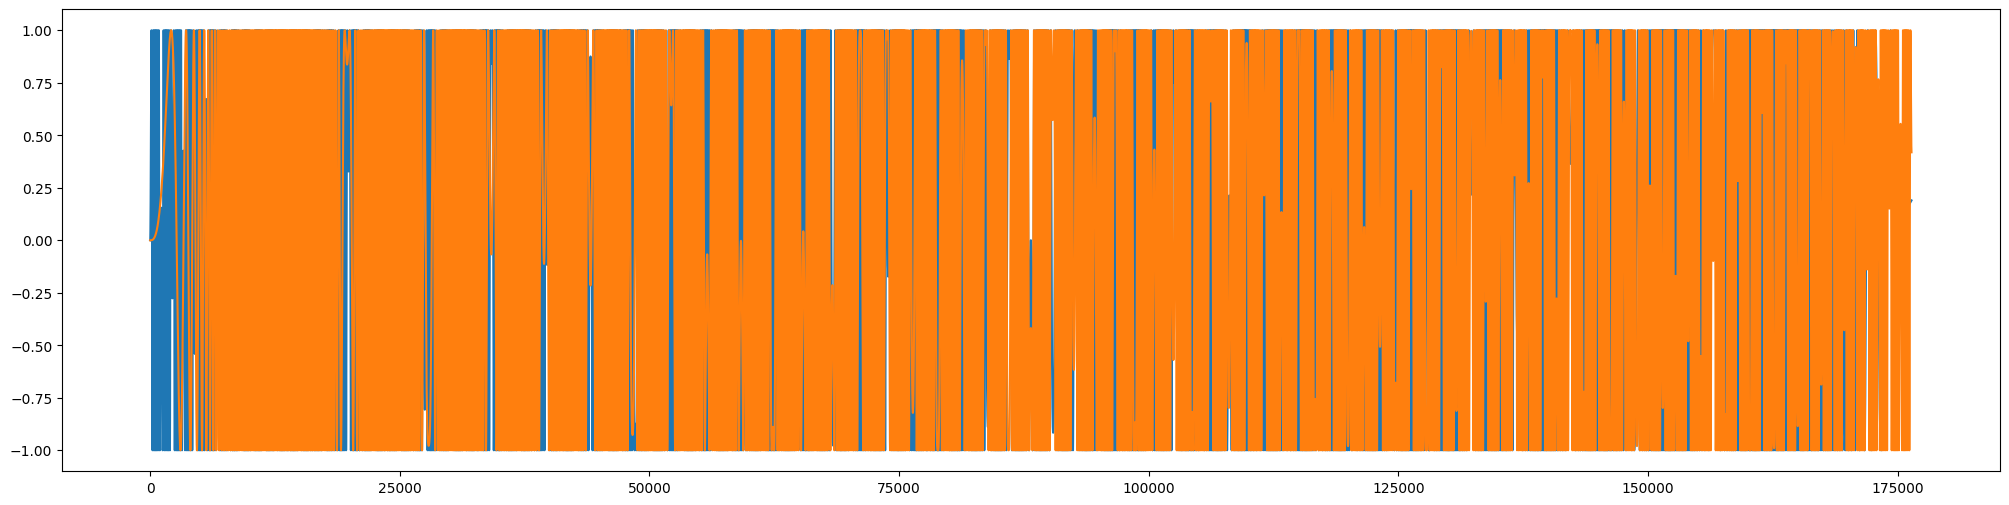

In [5]:
import IPython.display as ipd
from engine import (
    SineOscillator,
    ADSREnvelope,
    Panner,
    ModulatedOscillator,
    Chain,
    WaveAdder,
)

gen = Chain(
    WaveAdder(
        Chain(
            ModulatedOscillator(
                SineOscillator(hz("A4")),
                ModulatedOscillator(
                    SineOscillator(20), ADSREnvelope(0, 4, 0), freq_mod=amp_mod
                ),
                freq_mod=freq_mod,
            ),
            Panner(0),
        ),
        Chain(
            ModulatedOscillator(
                SineOscillator(hz("A4")),
                ModulatedOscillator(
                    SineOscillator(20), ADSREnvelope(4), freq_mod=amp_mod
                ),
                freq_mod=freq_mod,
            ),
            Panner(1),
        ),
        stereo=True,
    )
)

wav = gen.get_samples(int(DEFAULT_SAMPLE_RATE * 4))
plt.figure(figsize=(25, 6))
plt.plot(wav)
wave_to_file(wav, fname="accel_decel")
ipd.Audio(filename="accel_decel.wav")